In [25]:
# IMPORTING LIBRARIES
 
import numpy as np # numerical values
import pandas as pd # tables
import matplotlib.pyplot as plt # for plots
import joblib # set of tools for lightweight pipelining
import os

from sklearn.model_selection import train_test_split # splits the data into train and test sets 
from sklearn.preprocessing import StandardScaler # puts numerical features on the same scale to prevent larger values dominating
from sklearn.linear_model import LogisticRegression # creates a logistic regression model for classification
from sklearn.tree import DecisionTreeClassifier # creates a decision tree model for classification
from sklearn.dummy import DummyClassifier # a simple baseline classifier for comparison
from sklearn.tree import plot_tree # displays the decision tree as a diagram
from sklearn.tree import export_text # displays decision tree as text-based

pd.set_option("display.width", 120)
print("All libraries loaded :) ")

All libraries loaded :) 


In [26]:
# Loading dataset

df = pd.read_csv("~/Desktop/CARISURG/notebook-project/data/triage_cleaned_v1.csv")  # loading the clean dataset and not the raw one
print(f"Loaded {df.shape[0]:,} ED encounters x {df.shape[1]} columns")
df.head()

Loaded 55,121 ED encounters x 225 columns


,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,A,4,87,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,...,0,0,0,0,0,0,0,0,0,0
1,B,2,53,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,...,0,0,0,0,0,0,0,0,0,0
2,A,2,49,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,...,0,0,1,0,0,0,0,0,0,0
3,A,3,22,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,...,0,0,0,0,0,0,0,0,0,0
4,A,2,62,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,...,0,0,0,0,0,0,0,0,0,0


In [27]:
# COLUMNS NOT BEING INCLUDED
 
TARGET = "esi"
LEAKAGE = ["disposition", "previousdispo"]
NON_NUMERIC = ["dep_name", "gender", "ethnicity", "race", "lang", "religion", "maritalstatus", "employstatus", "insurance_status", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]

FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE if c not in NON_NUMERIC] # filters the dataset columns to keep valid input varibles.

P = df[FEATURES] # stores the input features used for making predictions.
e = df[TARGET] # stores the target variable the model will predict.

print(f"Model Inputs: {len(FEATURES)} features will be used to predict {TARGET}") # displays the number of input features and the target being predicted.
print(f"Example features being used: {FEATURES[:6]} ...") # displays the first few selected features used by the model.

Model Inputs: 209 features will be used to predict esi
Example features being used: ['age', 'triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_o2'] ...


In [28]:
# SPLITTING INTO TRAINING AND TEST

# Splitting the dataset into two sections:
# 1. Training set - used by the model to learn patterns. 80% of the dataset will be used.
# 2. Test set - used to evaluate model performance for unseen patients. 20% of the dataset will be used.

P_train, P_test, e_train, e_test = train_test_split(
    P,
    e,
    test_size = 0.2, # keeps 20% of the data for testing.
    stratify = e, # keeps the ESI class distribution balanced across both sets. 
    random_state=42 # ensures the same split is made each time.
)

print("Training patients:", P_train.shape[0])
print("Testing patients:", P_test.shape[0])



Training patients: 44096
Testing patients: 11025


In [29]:
# DUMMY CLASSIFIER - ML model that makes predictions using basic rules rather than learning patterns

dummy = DummyClassifier(strategy="stratified", random_state=42) # baseline classifier that makes random predictions based on class distribution
dummy.fit(P_train, e_train) # train the baseline model using the training
dummy_accuracy = dummy.score(P_test, e_test) # calculates the baseline model's accuracy on the test data

print("Dummy Model Accuracy:", round(dummy_accuracy, 3))



Dummy Model Accuracy: 0.375


In [30]:
# LOGISTIC REGRESSION AND STANDARD SCALER

# Logistic Regression - a statistical ML method used to predict the likelihood of a categorical event. 
# Standard Scaler -  data-processing took used in ML that puts different numbers in the same field. 
# every data will have a mean of 0 (centered) and a standard deviation of 1 (spread out evenly).

# Standard Scalar

scaler = StandardScaler() # creates a scalar (one type of a particular data class) to standardise the feature values

P_train_scale = scaler.fit_transform(P_train) # fits the scalar on the training data and scales it
P_test_scale = scaler.transform(P_test) # scales the test data with the same scalar

# Logistic Regression Model Scale

logreg = LogisticRegression(max_iter=1000, random_state=42) #logistic regression classifier
logreg.fit(P_train_scale, e_train) # trains the model using the scaled training data
logreg_accuracy = logreg.score(P_test_scale, e_test) # model accuracy

print("Logistic Regression Model Accuracy:", round(logreg_accuracy, 3))


Logistic Regression Model Accuracy: 0.683


In [31]:
# DECISION TREE 
# Decision Tree Classifier: an algorithm which uses a tree-like structure to classify instances. 

tree = DecisionTreeClassifier(max_depth=12, random_state=42) # sets the maximum length to 5 and 
tree.fit(P_train, e_train) # creates it on the unscaled P train (patient) and E train (ESI). 
tree_accuracy = tree.score(P_test, e_test) # calculates the accuracy of the model

# print("Decision Tree Model Accuracy:", round(tree_accuracy, 3))

print("Decision Tree Train Accuracy:", round(tree.score(P_train, e_train), 3))
print("Decision Tree Model Accuracy:", round(tree_accuracy, 3))

Decision Tree Train Accuracy: 0.62
Decision Tree Model Accuracy: 0.596


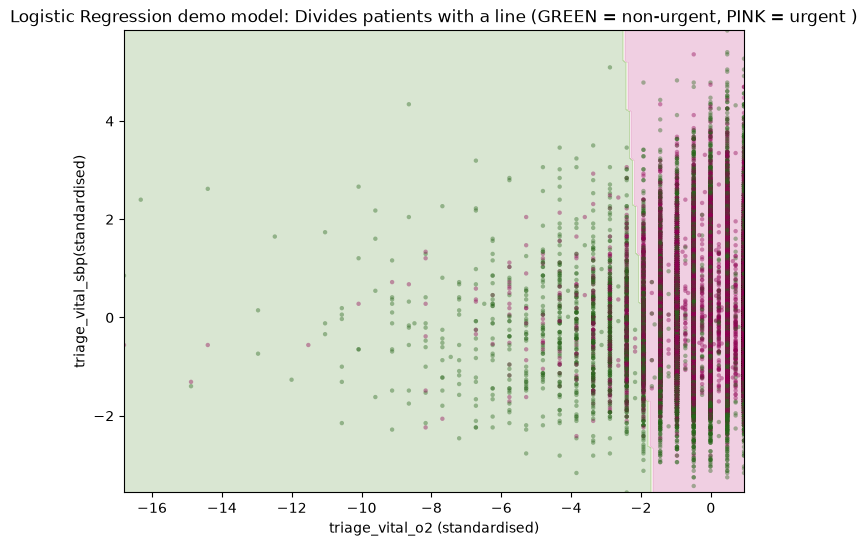

In [32]:
# VISUALISING THE LOGISTIC REGRESSION MODEL 

#  using heart rate and diastolic blood pressure.

f1, f2 ="triage_vital_o2", "triage_vital_sbp" # features for the X and Y axis

# making a two class label: urgent (ESI 1-2) and non-urgent (ESI 3-5)
urgent_levels = (e <= 2).astype(int) # creates a binary: 1 = Urgent ESI levels, 0 = Non-urgent ESI levels
two = StandardScaler().fit_transform(P[[f1, f2]]) # scales the two features together 
demo_model = LogisticRegression(max_iter=1000).fit(two, urgent_levels) # training a small logistics regression model

# converiing the plot with grid points and let the model classify each to have two decision regions.
xx, yy = np.meshgrid(np.linspace(two[:, 0].min(), two[:, 0].max(), 200),
                     np.linspace(two[:, 1].min(), two[:, 1].max(), 200))
zz = demo_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Creating a plot area
fig, ax = plt.subplots(figsize = (8, 6)) # creates a figure and axis with the chosen size

ax.contourf(xx, yy, zz, alpha=0.2, cmap="PiYG") # shows the decision regions created by the model
ax.scatter(two[:, 0], two[:,1], c=urgent_levels, cmap="PiYG", s=10, alpha=0.4, edgecolors="none") # plots patient data points
ax.set_xlabel(f1 + " (standardised)") # labels x axus
ax.set_ylabel(f2 + "(standardised)") # labels y axis 
ax.set_title("Logistic Regression demo model: Divides patients with a line (GREEN = non-urgent, PINK = urgent )") # title

os.makedirs("figs", exist_ok=True)

#print(os.getcwd())
plt.savefig("figs/logistic_regression_demo.png", dpi=120, bbox_inches="tight") # saves image into figs folder
plt.show()

|--- cc_abdominalpain <= 0.50
|   |--- triage_vital_o2_device <= 0.50
|   |   |--- cc_suicidal <= 0.50
|   |   |   |--- cc_alcoholintoxication <= 0.50
|   |   |   |   |--- truncated branch of depth 9
|   |   |   |--- cc_alcoholintoxication >  0.50
|   |   |   |   |--- truncated branch of depth 9
|   |   |--- cc_suicidal >  0.50
|   |   |   |--- cc_headache-recurrentorknowndxmigraines <= 0.50
|   |   |   |   |--- truncated branch of depth 9
|   |   |   |--- cc_headache-recurrentorknowndxmigraines >  0.50
|   |   |   |   |--- class: 3
|   |--- triage_vital_o2_device >  0.50
|   |   |--- cc_legpain <= 0.50
|   |   |   |--- cc_chestpain <= 0.50
|   |   |   |   |--- truncated branch of depth 9
|   |   |   |--- cc_chestpain >  0.50
|   |   |   |   |--- truncated branch of depth 9
|   |   |--- cc_legpain >  0.50
|   |   |   |--- age <= 90.50
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- age >  90.50
|   |   |   |   |--- class: 2
|--- cc_abdominalpain >  0.50
|   |--- triag

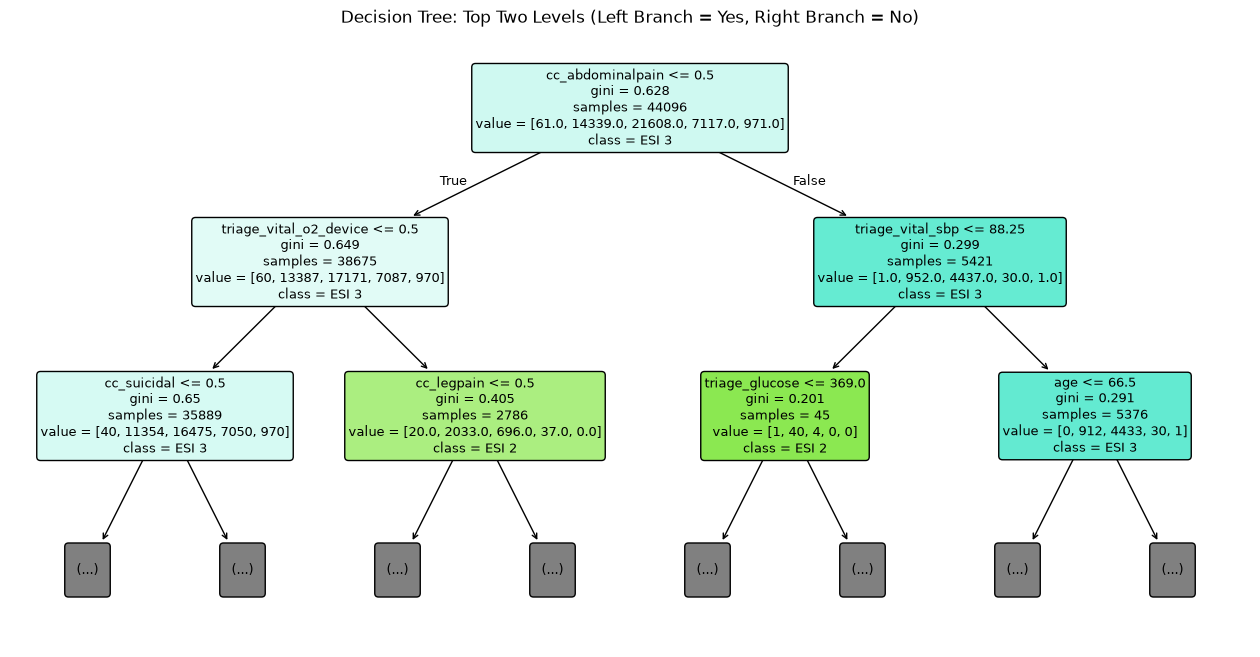

In [33]:
# VISUALISING THE DECISION TREE

fig, ax = plt.subplots(figsize=(16, 8)) 

plot_tree (
    tree, # uses the trained decision tree model
    feature_names=FEATURES, # labels  each split with the corresponding feature name
    class_names=[f"ESI {c}" for c in tree.classes_], #labels the output classes as ESI levels
    filled=True, # colours the nodes based on the predicted class
    rounded=True, # rounds the corner of each node for readability
    max_depth=2, # display sonly the furst two levels of the tree
    fontsize=9, 
    ax=ax, # draws the ree on the created axis
)

ax.set_title("Decision Tree: Top Two Levels (Left Branch = Yes, Right Branch = No)")
plt.savefig("figs/Decision_tree.png", dpi=120, bbox_inches="tight")

# Printing the decision tree as a text
print(export_text(tree, feature_names=list(FEATURES), max_depth=3))


In [34]:
# SAVING THE TRAINED DATA 

joblib.dump(logreg, "model_logistic_regression.joblib")
joblib.dump(tree, "model_decision_tree.joblib")
joblib.dump(scaler, "scaler.joblib")

print("All Models Saved: Decision tree, Scalar, Logistic Regression Saved ! :D")

All Models Saved: Decision tree, Scalar, Logistic Regression Saved ! :D


In [35]:
# RELOAD THE SAVED MODEL LATER

logreg_reloaded = joblib.load("model_logistic_regression.joblib") # trained logistic regression model
tree_reloaded   = joblib.load("model_decision_tree.joblib") # the trained decision tree
scaler_reloaded = joblib.load("scaler.joblib") # the same scalar used in training   

example = P_test.iloc[:5]  # a 5 patient demo
example_scaled = scaler_reloaded.transform(example)

print("Reloaded Logistic Regression Predictions:", logreg_reloaded.predict(example_scaled))
print("Reloaded Decision Tree Predictions:",  tree_reloaded.predict(example))
print("Does the reloaded models match the original?",
            (logreg_reloaded.predict(example_scaled) == logreg.predict(scaler.transform(example))).all())

Reloaded Logistic Regression Predictions: [2 3 3 2 2]
Reloaded Decision Tree Predictions: [2 3 3 3 2]
Does the reloaded models match the original? True


EXERCISE 8 ANSWERS:
1. random_state from 42 to 7. Dummy: 0.375 to 0.366, logreg: 0.683 to 0.679, Tree stayed the same and all moved less than 1 point.

2. max_depth at 3 => train(0.536), test(0.534). No gap present. max_depth at 12 => train(0.62), test (0.596). Open gaps present

3. Logistic regression wieghs all features together so the scale matters unless it is standardised. a tree splits one feature at a time so they scale does not affect it.

4. The root split is cc_abdominalpain (0.50). It is a sensible value as abdominal pain is a common complaint so it is a strong first fork for separating urgent from non-urgent. 
